In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import numpy as np, re, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader


In [2]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [3]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")
ds_sealevel = ds

In [4]:
ds_recent = ds.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [5]:
ds = ds_recent

In [6]:
from numba import njit
import numpy as np
import xarray as xr
from numba import njit

@njit(cache=True, fastmath=True)
def _mask_1d(values, k_eff, mean, std, safe_lo, safe_hi,
             hard_clip_eff, p95, p95_margin_eff,
             q1, q3, use_quantiles, iqr_mult):
    n = values.shape[0]
    dev = np.zeros(n, dtype=np.bool_)
    last_kept = np.nan; have_last=False; prev_was_kept=False
    z_enabled = np.isfinite(std) and std > 0.0
    p95_gate = p95 + p95_margin_eff if np.isfinite(p95) else np.inf
    iqr = q3 - q1
    lo_iqr = q1 - iqr_mult * iqr
    hi_iqr = q3 + iqr_mult * iqr
    for i in range(n):
        x = values[i]
        if not np.isfinite(x): dev[i]=True; prev_was_kept=False; continue
        if np.abs(x) > hard_clip_eff: dev[i]=True; prev_was_kept=False; continue
        if (x >= safe_lo) and (x <= safe_hi): dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True; continue
        if use_quantiles and ((x < lo_iqr) or (x > hi_iqr)): dev[i]=True; prev_was_kept=False; continue
        if z_enabled:
            z = (x - mean) / std
            if np.abs(z) > k_eff: dev[i]=True; prev_was_kept=False; continue
        if not prev_was_kept:
            if x <= p95_gate: dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
            else: dev[i]=True; prev_was_kept=False
            continue
        if have_last:
            allowed = 1.5 if (-1.0 <= last_kept <= 1.0) else 0.5
            if np.abs(x - last_kept) > allowed: dev[i]=True; prev_was_kept=False; continue
        dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
    return dev

# FAST block-drift mask: EW-quantile (median) + run-length
@njit(cache=True, fastmath=True)
def _block_mask_1d(values, med_thresh, min_run, alpha):
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    m = 0.0                        # EW median estimate (starts near 0 for residuals)
    run = 0                        # consecutive samples with |m| > threshold
    for i in range(n):
        x = values[i]
        if np.isfinite(x):
            # Robbins–Monro quantile update (tau=0.5 -> median)
            m += alpha * (0.5 - (1.0 if x < m else 0.0))
            if np.abs(m) > med_thresh:
                run += 1
                if run == min_run:
                    # backfill the initial block once threshold run is reached
                    start = i - min_run + 1
                    for j in range(start, i + 1):
                        block[j] = True
                elif run > min_run:
                    block[i] = True
            else:
                run = 0
        else:
            run = 0  # NaN breaks the block
    return block
@njit(cache=True, fastmath=True)
def _yrmean_block_mask_1d(values, yr_mean_vals, good_year_vals,
                          mean_abs_thresh, band, min_run):
    """
    Flag contiguous runs that stay near the (shifted) yearly mean, but only
    in years where |yearly mean| > mean_abs_thresh and coverage was 'good'.
    """
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    run = 0
    start = 0
    for i in range(n):
        x = values[i]
        if not np.isfinite(x):
            run = 0
            continue

        if not good_year_vals[i]:
            # year not eligible: reset run
            run = 0
            continue

        ymean = yr_mean_vals[i]
        if not np.isfinite(ymean) or (np.abs(ymean) <= mean_abs_thresh):
            # yearly mean not "shifted" enough
            run = 0
            continue

        # Are we "near" the shifted yearly mean?
        if np.abs(x - ymean) <= band:
            if run == 0:
                start = i
            run += 1
            if run == min_run:
                for j in range(start, i + 1):
                    block[j] = True
            elif run > min_run:
                block[i] = True
        else:
            run = 0
    return block
def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    base_k: float = 5.0,
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,
    station_dim: str = "station",
    min_frac_year: float = 0.5,
    kurt_hard: float = 1.0,
    # mean-shift block knobs
    year_mean_abs_thresh: float = 1.0,   # consider a year "shifted" if |year mean| > 1 m
    block_band: float = 0.5,             # samples within ±band of the yearly mean count toward a block
    min_run: int = 60,                   # consecutive samples near the mean to declare a block
):
    da = ds[var]; dim = da.dims[0] if dim is None else dim
    ds = ds.sortby(dim); da = ds[var].astype("float64")

    # --- robust stats (unchanged)
    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)
    qs   = da.quantile([0.25, 0.75], dim=dim, skipna=True)
    q1, q3 = qs.sel(quantile=0.25), qs.sel(quantile=0.75)

    m2 = da.var(dim=dim, skipna=True)
    m4 = ((da - mu) ** 4).mean(dim=dim, skipna=True)
    ex_kurt = xr.where(m2 > 0, m4 / (m2 ** 2) - 3.0, 0.0)
    heavy = ex_kurt > kurt_hard

    k_eff          = xr.where(heavy, base_k / 2.5, base_k)
    iqr_mult       = xr.where(heavy, 1.0, 1.5)
    hard_clip_eff  = xr.where(heavy, 2.0, hard_clip)
    p95_margin_eff = xr.where(heavy, 0.1, p95_margin)
    use_quantiles  = heavy

    dev_point = xr.apply_ufunc(
        _mask_1d,
        da, k_eff, mu, sig,
        xr.DataArray(safe_keep_band[0]), xr.DataArray(safe_keep_band[1]),
        hard_clip_eff, p95, p95_margin_eff,
        q1, q3, use_quantiles, iqr_mult,
        input_core_dims=[[dim], [], [], [], [], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    # --- yearly mean and coverage (unchanged)
    present = da.notnull()
    cov_year = present.groupby(f"{dim}.year").mean(dim=dim)         # fraction present per year
    yr_mean  = da.groupby(f"{dim}.year").mean(dim=dim, skipna=True)  # mean per year
    good_year = cov_year > min_frac_year

    # --- NEW: broadcast per-year values back to each timestamp by selecting with a per-sample 'year' indexer
    # Ensure time axis is datetime64
    if not np.issubdtype(ds[dim].dtype, np.datetime64):
        # If your coord isn't datetime64, convert it here (one-time)
        ds = ds.assign_coords({dim: xr.converters.to_datetime64(ds[dim])})
        da = ds[var].astype("float64")

    year_indexer = xr.DataArray(
        ds[dim].dt.year,         # vector of years for every sample along `dim`
        dims=dim,
        coords={dim: ds[dim]}
    )

    # These now have the SAME dims as `da` (broadcasted back from 'year')
    yr_mean_full   = yr_mean.sel(year=year_indexer)
    good_year_full = good_year.sel(year=year_indexer)

    # --- block detector: runs near the shifted yearly mean
    dev_block = xr.apply_ufunc(
        _yrmean_block_mask_1d,
        da,
        yr_mean_full,
        good_year_full,
        xr.DataArray(year_mean_abs_thresh),
        xr.DataArray(block_band),
        xr.DataArray(np.int64(min_run)),
        input_core_dims=[[dim], [dim], [dim], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    deviant = dev_point | dev_block

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    if station_dim in out.dims:
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        cov_check = cov_year if not extra else cov_year.mean(dim=extra)
        keep_station = (cov_check > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]
# ds: xr.Dataset with a variable named "residual" along dimension "time"
ds_filtered, dev_mask = filter_residual(ds_recent, var="residual", dim="valid_time")
ds = ds_filtered

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [7]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [8]:
ds_engineered = ds_engineered.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [9]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
features_df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
features_df = features_df.dropna(subset=[target])

# ADd bathymetry_stats

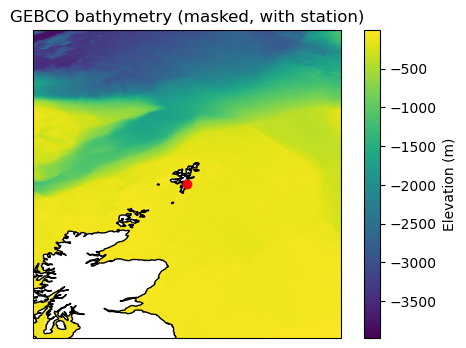

In [10]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['station_latitude'].values
lons = ds_sealevel['station_longitude'].values
station = ds_sealevel['station'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

plot_tile(results["10.0x10.0"][0])

In [11]:
import numpy as np, re, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# --- simple helpers reused from earlier ---
def _label_from_key(k):
    s = str(k)
    m = re.match(r'^\s*([0-9]*\.?[0-9]+)\s*x', s)  # "0.25x0.25" -> "0.25"
    if m: return f"{float(m.group(1)):g}"
    try:   return f"{float(s):g}"                  # "1.0" -> "1"
    except: return s.strip()

def to_128x128(ds_tile, var='elevation'):
    v = ds_tile[var].sortby(['lat','lon'])
    lat_new = np.linspace(float(v['lat'].min()), float(v['lat'].max()), 128)
    lon_new = np.linspace(float(v['lon'].min()), float(v['lon'].max()), 128)
    v128 = v.interp(lat=lat_new, lon=lon_new)
    arr = v128.values.astype(np.float32)
    return arr

def prep_image(arr):
    # fill NaNs (masked land) and standardize per-tile (mean/std) for stable training
    arr = np.nan_to_num(arr, nan=0.0)
    m, s = float(arr.mean()), float(arr.std() + 1e-6)
    arr = (arr - m) / s
    return arr[None, ...]  # (1, 128, 128)
def collect_tiles_for_resolution(results_by_station, res_label, var='elevation', stations_subset=None):
    """Return list of (station_str, np.ndarray[1,128,128]) for a given resolution label."""
    items = []
    for stn, tiles in results_by_station.items():
        if stations_subset is not None and stn not in stations_subset:
            continue
        if res_label in tiles:
            arr = to_128x128(tiles[res_label], var=var)
            items.append((str(stn), prep_image(arr)))
    return items


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset

def _standardize01(x):
    x = np.asarray(x, np.float32)
    x = np.nan_to_num(x, nan=0.0)
    m, s = float(x.mean()), float(x.std() + 1e-6)
    return (x - m) / s

def _grad_channels(x2d):
    # x2d: (128,128) float32
    gy, gx = np.gradient(x2d)                 # dy, dx
    mag = np.sqrt(gx*gx + gy*gy)
    ang = np.arctan2(gy, gx)                  # aspect in radians
    sin_a, cos_a = np.sin(ang), np.cos(ang)
    # standardize each channel to balance scales
    return (_standardize01(mag),
            _standardize01(sin_a),
            _standardize01(cos_a))

def _rand_rot_flip(arr):
    # arr: (C,H,W) numpy; random 0/90/180/270 + optional hflip/vflip
    k = np.random.randint(0, 4)
    out = np.rot90(arr, k, axes=(1,2)).copy()
    if np.random.rand() < 0.5: out = out[:, :, ::-1]
    if np.random.rand() < 0.5: out = out[:, ::-1, :]
    return out

class TilesEdgeDataset(Dataset):
    """
    items[i]['x'] is (1,128,128) float32 elevation (standardized per-tile).
    This dataset builds 4 channels: [elev_z, |∇|, sin(aspect), cos(aspect)].
    If train=True, applies small rotation/flip aug.
    """
    def __init__(self, items, train=False):
        self.items = items
        self.train = train

    def __len__(self): return len(self.items)

    def __getitem__(self, i):
        x = self.items[i]['x'][0]                  # (128,128) elevation
        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        elev_z = _standardize01(x)
        mag, sin_a, cos_a = _grad_channels(x)
        arr = np.stack([elev_z, mag, sin_a, cos_a], axis=0)  # (4,128,128)
        if self.train:
            arr = _rand_rot_flip(arr)
        return torch.from_numpy(arr), self.items[i]['station']


In [12]:
import torch
import torch.nn as nn

class TinyPatchMAE(nn.Module):
    """
    Multi-channel MAE with:
      - patch_size default 8 (better for fine detail)
      - mask_strategy='random' or 'variance' (mask highest-variance patches)
      - edge_loss term on per-patch gradients
    """
    def __init__(self, in_ch=4, patch_size=8, embed_dim=64, encoder_layers=2, decoder_layers=1,
                 nhead=4, mlp_ratio=2.0, mask_ratio=0.6, mask_strategy='random',
                 lambda_edge=0.3):
        super().__init__()
        assert 128 % patch_size == 0
        self.in_ch = in_ch
        self.patch = patch_size
        self.num_patches = (128 // patch_size) ** 2
        self.patch_dim = patch_size * patch_size * in_ch
        self.mask_ratio = mask_ratio
        self.mask_strategy = mask_strategy
        self.lambda_edge = float(lambda_edge)

        self.proj = nn.Linear(self.patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

        enc = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                         dim_feedforward=int(embed_dim*mlp_ratio),
                                         batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=encoder_layers)

        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        dec = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                         dim_feedforward=int(embed_dim*mlp_ratio),
                                         batch_first=True)
        self.decoder = nn.TransformerEncoder(dec, num_layers=decoder_layers)
        self.pred = nn.Linear(embed_dim, self.patch_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def _patchify(self, x):
        # x: (B,C,128,128) -> (B, N, C*P*P)
        B, C, H, W = x.shape
        p = self.patch
        x = x.unfold(2, p, p).unfold(3, p, p)             # (B,C,H/p,W/p,p,p)
        x = x.contiguous().view(B, C, (H//p)*(W//p), p, p)
        x = x.permute(0, 2, 1, 3, 4).contiguous()         # (B,N,C,p,p)
        return x.view(B, -1, C*p*p), C, p                 # (B,N,D_patch)

    def _mask_indices(self, patches):
        # patches: (B,N,Pdim) BEFORE projection
        B, N, Dp = patches.shape
        num_keep = max(1, int((1.0 - self.mask_ratio) * N))
        device = patches.device
        if self.mask_strategy == 'variance':
            # variance per patch as edge-ish proxy
            var = patches.var(dim=2)                      # (B,N)
            # mask highest variance patches
            ids_mask = torch.topk(var, k=N - num_keep, dim=1, largest=True).indices
            ids = torch.argsort(var, dim=1)               # increasing var
            ids_keep = ids[:, :num_keep]
            ids_restore = torch.argsort(torch.cat([ids_keep, ids_mask], dim=1), dim=1)
            return ids_keep, ids_mask, ids_restore
        else:
            ids = torch.argsort(torch.rand(B, N, device=device), dim=1)
            ids_keep = ids[:, :num_keep]
            ids_mask = ids[:, num_keep:]
            ids_restore = torch.argsort(ids, dim=1)
            return ids_keep, ids_mask, ids_restore

    def _patch_grad_loss(self, pred_masked, target_masked, p, C):
        # pred_masked/target_masked: (B, N_mask, C*p*p) -> (-1, C, p, p)
        B, Nm, Dp = pred_masked.shape
        if Nm == 0: return pred_masked.mean()*0.0
        pred = pred_masked.view(-1, C, p, p)
        targ = target_masked.view(-1, C, p, p)
        # finite-diff grads inside each patch (channel-wise), sum over channels
        def grads(t):
            dx = t[:, :, :, 1:] - t[:, :, :, :-1]
            dy = t[:, :, 1:, :] - t[:, :, :-1, :]
            return dx, dy
        pdx, pdy = grads(pred)
        tdx, tdy = grads(targ)
        # MSE on gradients (edges)
        return ((pdx - tdx)**2).mean() + ((pdy - tdy)**2).mean()

    def forward(self, imgs):
        # imgs: (B,in_ch,128,128)
        patches, C, p = self._patchify(imgs)          # (B,N,Dp)
        tokens = self.proj(patches)                   # (B,N,D)
        B, N, D = tokens.shape
        pos = self.pos_embed.expand(B, -1, -1)

        ids_keep, ids_mask, _ = self._mask_indices(patches)
        x_vis = torch.gather(tokens, 1, ids_keep[..., None].expand(-1,-1,D)) + \
                torch.gather(pos,    1, ids_keep[..., None].expand(-1,-1,D))

        z = self.encoder(x_vis)                       # (B,N_vis,D)

        N_vis = z.size(1)
        N_mask = N - N_vis
        mask_tokens = self.mask_token.expand(B, N_mask, D)

        x_full = torch.zeros(B, N, D, device=imgs.device)
        x_full.scatter_(1, ids_keep[..., None].expand(-1,-1,D), z)
        x_full.scatter_(1, ids_mask[..., None].expand(-1,-1,D), mask_tokens)
        x_full = x_full + pos

        y = self.decoder(x_full)
        pred = self.pred(y)                           # (B,N,Dp)
        target = patches

        # pixel MSE on masked patches only
        sel = ids_mask[..., None].expand(-1,-1,self.patch_dim)
        loss_pix = ((pred.gather(1, sel) - target.gather(1, sel))**2).mean()

        # add gradient loss on masked patches
        loss_edge = self._patch_grad_loss(pred.gather(1, sel), target.gather(1, sel), p, C)

        return loss_pix + self.lambda_edge * loss_edge

    @torch.no_grad()
    def embed(self, imgs):
        patches, _, _ = self._patchify(imgs)
        tokens = self.proj(patches)
        B, N, D = tokens.shape
        pos = self.pos_embed.expand(B, -1, -1)
        z = self.encoder(tokens + pos)
        return z.mean(dim=1)  # (B,D)


In [14]:
# Train/val split by station stays the same
items_tr, items_va, _ = split_items_by_station(items_all, val_frac=0.15, seed=0)
dl_tr = DataLoader(TilesEdgeDataset(items_tr, train=True),  batch_size=16, shuffle=True,  num_workers=0)
dl_va = DataLoader(TilesEdgeDataset(items_va, train=False), batch_size=16, shuffle=False, num_workers=0)

device = 'cpu'
mae = TinyPatchMAE(in_ch=4, patch_size=8, embed_dim=64,
                   mask_ratio=0.6, mask_strategy='variance',
                   lambda_edge=0.3).to(device)
opt = torch.optim.AdamW(mae.parameters(), lr=1e-3, weight_decay=1e-4)

hist=[]
for ep in range(1, 61):  # e.g., 60 epochs
    mae.train(); tr_sum=0; ntr=0
    for xb,_ in dl_tr:
        xb = xb.to(device)
        opt.zero_grad(set_to_none=True)
        loss = mae(xb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mae.parameters(), 1.0)
        opt.step()
        tr_sum += float(loss)*xb.size(0); ntr += xb.size(0)
    tr = tr_sum/max(1,ntr)

    mae.eval(); va_sum=0; nva=0
    with torch.no_grad():
        for xb,_ in dl_va:
            xb = xb.to(device)
            loss = mae(xb)
            va_sum += float(loss)*xb.size(0); nva += xb.size(0)
    va = va_sum/max(1,nva)
    hist.append((ep,tr,va))
    if ep % 5 == 0:
        print(f"ep{ep:03d} train {tr:.4f} val {va:.4f}")


NameError: name 'split_items_by_station' is not defined

In [13]:
class TinyPatchMAE(nn.Module):
    """
    Minimal MAE:
      - Patchify 128x128 into (P x P) patches (default P=16 -> 64 patches).
      - Encoder: tiny Transformer (2 layers).
      - Decoder: tiny Transformer (1 layer) to reconstruct masked patches.
      - Embedding: mean of encoder tokens (no [CLS]) -> fixed-length vector.
    """
    def __init__(self, patch_size=16, embed_dim=128, encoder_layers=2, decoder_layers=1, nhead=4, mlp_ratio=2.0, mask_ratio=0.6):
        super().__init__()
        assert 128 % patch_size == 0
        self.patch = patch_size
        self.num_patches = (128 // patch_size) ** 2
        self.patch_dim = patch_size * patch_size  # grayscale
        self.mask_ratio = mask_ratio

        # patch embed
        self.proj = nn.Linear(self.patch_dim, embed_dim)

        # learnable 2D pos embedding (N, D)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

        # encoder
        enc_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=int(embed_dim*mlp_ratio), batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=encoder_layers)

        # decoder: uses mask tokens + pos
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        dec_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=int(embed_dim*mlp_ratio), batch_first=True)
        self.decoder = nn.TransformerEncoder(dec_layer, num_layers=decoder_layers)
        self.pred = nn.Linear(embed_dim, self.patch_dim)  # predict pixels per patch

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    # ---- utilities ----
    def _patchify(self, x):
        # x: (B,1,128,128) -> patches (B, N, P*P)
        B, _, H, W = x.shape
        p = self.patch
        x = x.unfold(2, p, p).unfold(3, p, p)  # (B,1,H/p,W/p,p,p)
        x = x.contiguous().view(B, 1, (H//p)*(W//p), p, p)
        x = x.squeeze(1).flatten(2)            # (B, N, P*P)
        return x

    def _unpatchify(self, patches):
        # patches: (B, N, P*P) -> (B,1,128,128)
        B, N, D = patches.shape
        p = self.patch
        G = int((N) ** 0.5)
        x = patches.view(B, G, G, p, p).permute(0,3,1,4,2)  # (B,p,G,p,G)
        x = x.reshape(B, 1, G*p, G*p)
        return x

    def _random_mask(self, N, B, device):
        # returns: ids_keep, ids_mask, ids_restore per sample
        ids = torch.argsort(torch.rand(B, N, device=device), dim=1)
        num_keep = int((1.0 - self.mask_ratio) * N)
        ids_keep = ids[:, :num_keep]
        ids_mask = ids[:, num_keep:]
        # restore index positions
        ids_restore = torch.argsort(ids, dim=1)
        return ids_keep, ids_mask, ids_restore

    # ---- forward passes ----
    def forward(self, imgs):
        # imgs: (B,1,128,128)
        patches = self._patchify(imgs)                # (B,N,P^2)
        tokens = self.proj(patches)                   # (B,N,D)
        B, N, D = tokens.shape
        pos = self.pos_embed.expand(B, -1, -1)        # (B,N,D)

        ids_keep, ids_mask, ids_restore = self._random_mask(N, B, tokens.device)

        # gather visible tokens + pos
        x_vis = torch.gather(tokens, 1, ids_keep.unsqueeze(-1).expand(-1,-1,D))
        pos_vis = torch.gather(pos,    1, ids_keep.unsqueeze(-1).expand(-1,-1,D))
        x_vis = x_vis + pos_vis

        # encoder
        z = self.encoder(x_vis)                       # (B, N_vis, D)

        # decoder input: put encoded tokens back with mask tokens, then add pos
        B, N_vis, D = z.shape
        N_mask = N - N_vis
        mask_tokens = self.mask_token.expand(B, N_mask, D)
        x_full = torch.zeros(B, N, D, device=imgs.device)
        x_full.scatter_(1, ids_keep.unsqueeze(-1).expand(-1,-1,D), z)
        x_full.scatter_(1, ids_mask.unsqueeze(-1).expand(-1,-1,D), mask_tokens)
        x_full = x_full + pos

        y = self.decoder(x_full)                      # (B,N,D)
        pred = self.pred(y)                           # (B,N,P^2)

        # loss on masked patches only
        target = patches
        loss = ((pred.gather(1, ids_mask.unsqueeze(-1).expand(-1,-1,self.patch_dim)) -
                 target.gather(1, ids_mask.unsqueeze(-1).expand(-1,-1,self.patch_dim))) ** 2).mean()
        return loss, pred, ids_mask

    @torch.no_grad()
    def embed(self, imgs):
        """Return mean-pooled encoder tokens as the embedding (B, D)."""
        patches = self._patchify(imgs)
        tokens = self.proj(patches)
        B, N, D = tokens.shape
        pos = self.pos_embed.expand(B, -1, -1)
        # no masking for embedding
        x = tokens + pos
        z = self.encoder(x)
        return z.mean(dim=1)  # (B, D)

In [14]:
import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Quick, vectorized resize of a GEBCO tile to (H,W) using xarray's interp.
    Works for all numeric vars defined on (lat, lon). Keeps dask laziness.
    """
    # Build uniform target coords spanning the tile extent (ascending)
    lat0, lat1 = float(ds_tile.lat.min()), float(ds_tile.lat.max())
    lon0, lon1 = float(ds_tile.lon.min()), float(ds_tile.lon.max())
    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    # Interpolate all variables defined on (lat, lon)
    return ds_tile.interp(lat=new_lat, lon=new_lon, method="linear")

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

In [15]:
def collect_tiles_for_resolution(results_128, res_label, *, var='elevation',
                                 unique_latlon=None, latlon_to_station=None):
    """
    For results_128[res_label] as a *list* of xr.Dataset tiles (lat,lon = 128x128),
    return: list of (station_str, np.ndarray[1,128,128]) suitable for the MAE.
    Uses either index alignment with unique_latlon OR nearest-neighbour fallback.
    """
    bucket = results_128.get(res_label, None)
    if bucket is None:
        return []
    if not isinstance(bucket, (list, tuple)):
        raise TypeError(f"Expected list/tuple for results_128['{res_label}'], got {type(bucket)}")

    if unique_latlon is None or latlon_to_station is None:
        raise ValueError("Provide unique_latlon and latlon_to_station for mapping tiles → station id.")

    items = []

    # ---- Fast path: index alignment (list order == unique_latlon order) ----
    if len(bucket) == len(unique_latlon):
        for i, tile in enumerate(bucket):
            lat_i, lon_i = unique_latlon[i]
            stn = latlon_to_station[(float(lat_i), float(lon_i))]
            arr = tile[var].values.astype(np.float32)
            arr = np.nan_to_num(arr, nan=0.0)
            m, s = float(arr.mean()), float(arr.std() + 1e-6)
            arr = (arr - m) / s
            items.append((str(int(stn)), arr[None, ...]))  # (1,128,128)
        return items

    # ---- Robust fallback: map by tile center → nearest station (BallTree) ----
    from sklearn.neighbors import BallTree
    R = 6371000.0  # m
    coords = np.deg2rad(np.array(unique_latlon))         # (N,2)
    tree = BallTree(coords, metric='haversine')

    for tile in bucket:
        c_lat = float(tile['lat'].values.mean())
        c_lon = float(tile['lon'].values.mean())
        dist_rad, idx = tree.query(np.deg2rad([[c_lat, c_lon]]), k=1)
        j = int(idx[0, 0])
        lat_j, lon_j = unique_latlon[j]
        stn = latlon_to_station[(float(lat_j), float(lon_j))]

        arr = tile[var].values.astype(np.float32)
        arr = np.nan_to_num(arr, nan=0.0)
        m, s = float(arr.mean()), float(arr.std() + 1e-6)
        arr = (arr - m) / s
        items.append((str(int(stn)), arr[None, ...]))
    return items


In [16]:
# ========= 0) Safety + imports =========
import os, re, numpy as np, pandas as pd
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
torch.set_num_threads(1)
torch.manual_seed(0); np.random.seed(0)


[MAE] in_ch=4 | patch=8 | num_patches=256 | patch_dim=256 | proj.in=256


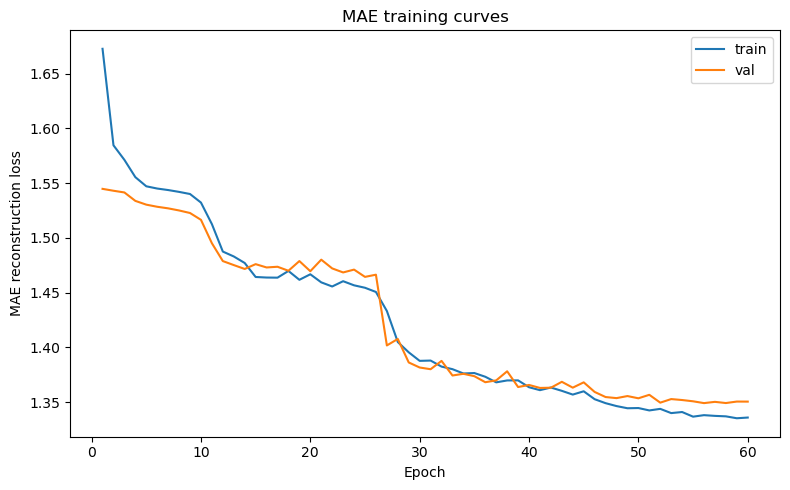

[enc] df_mae_long: (900, 68)
[enc] df_enc_stations: (180, 323)


In [18]:
# ==== FULL CELL: Edge-aware MAE with safe aug (no negative strides), train/encode ====
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------------- helpers to build items --------------------------
def _label_from_key(k):
    s = str(k)
    m = re.match(r'^\s*([0-9]*\.?[0-9]+)', s)
    if m: return f"{float(m.group(1)):g}"
    try:   return f"{float(s):g}"
    except: return s.strip()

def _round_key(lat, lon, prec=5):
    return (round(float(lat), prec), round(float(lon), prec))

def ds_to_array(ds, var='elevation'):
    arr = np.asarray(ds[var].values, dtype=np.float32)
    if arr.ndim == 3: arr = arr[0]
    assert arr.shape == (128,128), f"expected (128,128), got {arr.shape}"
    return np.clip(arr, -1e4, 1e4)

def build_items_from_bucket(bucket, unique_latlon, latlon_to_station, var='elevation'):
    items = []
    if len(bucket) == len(unique_latlon):
        for (lat, lon), ds in zip(unique_latlon, bucket):
            stn = latlon_to_station.get((float(lat), float(lon))) or latlon_to_station.get(_round_key(lat, lon))
            if stn is None: continue
            x2d = ds_to_array(ds, var=var)
            items.append({'station': str(int(stn)), 'lat': float(lat), 'lon': float(lon), 'x': x2d[None, ...]})
        return items
    for ds in bucket:
        lat_c = float(np.mean(ds['lat'].values)); lon_c = float(np.mean(ds['lon'].values))
        stn = latlon_to_station.get((lat_c, lon_c)) or latlon_to_station.get(_round_key(lat_c, lon_c))
        if stn is None: continue
        x2d = ds_to_array(ds, var=var)
        items.append({'station': str(int(stn)), 'lat': lat_c, 'lon': lon_c, 'x': x2d[None, ...]})
    return items

# -------------------------- Dataset (4-channel: elev, |∇|, sin, cos) --------------------------
def _std01(a):
    a = a.astype(np.float32)
    return (a - a.mean()) / (a.std() + 1e-6)

class TilesEdgeDataset(Dataset):
    def __init__(self, items, train=False):
        self.items = items; self.train = train
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        x = self.items[i]['x'][0].astype(np.float32)         # (128,128)
        x = np.nan_to_num(x, nan=0.0)
        m, s = float(x.mean()), float(x.std() + 1e-6)
        elev = (x - m) / s
        gy, gx = np.gradient(x); mag = np.sqrt(gx*gx + gy*gy)
        ang = np.arctan2(gy, gx); sin_a, cos_a = np.sin(ang), np.cos(ang)
        arr = np.stack([elev, _std01(mag), _std01(sin_a), _std01(cos_a)], axis=0)  # (4,128,128)

        # Safe augmentation (avoid negative strides)
        if self.train:
            k = np.random.randint(0, 4)
            if k: arr = np.rot90(arr, k, axes=(1,2)).copy()     # copy() makes it C-contiguous
            if np.random.rand() < 0.5: arr = np.flip(arr, axis=2).copy()  # horizontal flip
            if np.random.rand() < 0.5: arr = np.flip(arr, axis=1).copy()  # vertical flip

        # Ensure contiguous for torch
        arr = np.ascontiguousarray(arr)
        return torch.from_numpy(arr), self.items[i]['station']

# -------------------------- MAE (edge-aware) --------------------------
class TinyPatchMAE(nn.Module):
    def __init__(self, in_ch=4, patch_size=8, embed_dim=64, encoder_layers=2, decoder_layers=1,
                 nhead=4, mlp_ratio=2.0, mask_ratio=0.6, mask_strategy='random',
                 lambda_edge=0.3):
        super().__init__()
        assert 128 % patch_size == 0
        self.in_ch = int(in_ch)
        self.patch = int(patch_size)
        self.num_patches = (128 // self.patch) ** 2
        self.patch_dim = self.patch * self.patch * self.in_ch
        self.mask_ratio = mask_ratio
        self.mask_strategy = mask_strategy
        self.lambda_edge = float(lambda_edge)

        self.proj = nn.Linear(self.patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

        enc = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                         dim_feedforward=int(embed_dim*mlp_ratio),
                                         batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=encoder_layers)

        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        dec = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                         dim_feedforward=int(embed_dim*mlp_ratio),
                                         batch_first=True)
        self.decoder = nn.TransformerEncoder(dec, num_layers=decoder_layers)
        self.pred = nn.Linear(embed_dim, self.patch_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        print(f"[MAE] in_ch={self.in_ch} | patch={self.patch} | num_patches={self.num_patches} | patch_dim={self.patch_dim} | proj.in={self.proj.in_features}")

    def _patchify(self, x):
        B, C, H, W = x.shape
        p = self.patch
        x = x.unfold(2, p, p).unfold(3, p, p)      # (B,C,H/p,W/p,p,p)
        x = x.contiguous().view(B, C, (H//p)*(W//p), p, p)
        x = x.permute(0, 2, 1, 3, 4).contiguous()  # (B,N,C,p,p)
        return x.view(B, -1, C*p*p), C, p

    def _mask_indices(self, patches):
        B, N, _ = patches.shape
        num_keep = max(1, int((1.0 - self.mask_ratio) * N))
        device = patches.device
        if self.mask_strategy == 'variance':
            var = patches.var(dim=2)
            ids_mask = torch.topk(var, k=N - num_keep, dim=1, largest=True).indices
            ids = torch.argsort(var, dim=1)
            ids_keep = ids[:, :num_keep]
            ids_restore = torch.argsort(torch.cat([ids_keep, ids_mask], dim=1), dim=1)
            return ids_keep, ids_mask, ids_restore
        else:
            ids = torch.argsort(torch.rand(B, N, device=device), dim=1)
            ids_keep = ids[:, :num_keep]; ids_mask = ids[:, num_keep:]
            ids_restore = torch.argsort(ids, dim=1)
            return ids_keep, ids_mask, ids_restore

    def _patch_grad_loss(self, pred_masked, target_masked, p, C):
        B, Nm, Dp = pred_masked.shape
        if Nm == 0: return pred_masked.mean()*0.0
        pred = pred_masked.view(-1, C, p, p)
        targ = target_masked.view(-1, C, p, p)
        def grads(t):
            dx = t[:, :, :, 1:] - t[:, :, :, :-1]
            dy = t[:, :, 1:, :] - t[:, :, :-1, :]
            return dx, dy
        pdx, pdy = grads(pred); tdx, tdy = grads(targ)
        return ((pdx - tdx)**2).mean() + ((pdy - tdy)**2).mean()

    def forward(self, imgs):
        assert imgs.dim()==4 and imgs.shape[1]==self.in_ch, f"Channel mismatch: expect C={self.in_ch}, got {tuple(imgs.shape)}"
        patches, C, p = self._patchify(imgs)
        tokens = self.proj(patches)
        B, N, D = tokens.shape
        pos = self.pos_embed.expand(B, -1, -1)

        ids_keep, ids_mask, _ = self._mask_indices(patches)
        x_vis = torch.gather(tokens, 1, ids_keep[..., None].expand(-1,-1,D)) + \
                torch.gather(pos,    1, ids_keep[..., None].expand(-1,-1,D))
        z = self.encoder(x_vis)

        N_vis = z.size(1); N_mask = N - N_vis
        mask_tokens = self.mask_token.expand(B, N_mask, D)
        x_full = torch.zeros(B, N, D, device=imgs.device)
        x_full.scatter_(1, ids_keep[..., None].expand(-1,-1,D), z)
        x_full.scatter_(1, ids_mask[..., None].expand(-1,-1,D), mask_tokens)
        x_full = x_full + pos

        y = self.decoder(x_full)
        pred = self.pred(y)   # (B,N,Dp)
        target = patches

        sel = ids_mask[..., None].expand(-1,-1,self.patch_dim)
        loss_pix  = ((pred.gather(1, sel) - target.gather(1, sel))**2).mean()
        loss_edge = self._patch_grad_loss(pred.gather(1, sel), target.gather(1, sel), p, C)
        return loss_pix + self.lambda_edge * loss_edge

    @torch.no_grad()
    def embed(self, imgs):
        assert imgs.shape[1]==self.in_ch
        patches, _, _ = self._patchify(imgs)
        tokens = self.proj(patches)
        z = self.encoder(tokens + self.pos_embed.expand(tokens.size(0), -1, -1))
        return z.mean(dim=1)

# -------------------------- split, train, encode --------------------------
def split_items_by_station(items, val_frac=0.15, seed=0):
    sids = sorted(set(it['station'] for it in items))
    rng = np.random.default_rng(seed)
    k_val = max(1, int(len(sids) * val_frac))
    val_sids = set(rng.choice(sids, size=k_val, replace=False))
    tr = [it for it in items if it['station'] not in val_sids]
    va = [it for it in items if it['station'] in val_sids]
    return tr, va, val_sids

def train_mae_with_curves(items_all, *, epochs=60, batch_size=16, embed_dim=64,
                          mask_ratio=0.6, lr=1e-3, weight_decay=1e-4,
                          device='cpu', seed=0, patience=8, use_plateau=True):
    torch.manual_seed(seed); np.random.seed(seed)
    items_tr, items_va, _ = split_items_by_station(items_all, val_frac=0.15, seed=seed)
    dl_tr = DataLoader(TilesEdgeDataset(items_tr, train=True),  batch_size=batch_size, shuffle=True,  num_workers=0)
    dl_va = DataLoader(TilesEdgeDataset(items_va, train=False), batch_size=batch_size, shuffle=False, num_workers=0)

    mae = TinyPatchMAE(in_ch=4, patch_size=8, embed_dim=embed_dim,
                       mask_ratio=mask_ratio, mask_strategy='variance', lambda_edge=0.3).to(device)
    opt = torch.optim.AdamW(mae.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3, verbose=False) if use_plateau else None

    best_val = float('inf'); best_state = None; bad = 0
    hist = []
    for ep in range(1, epochs+1):
        mae.train(); train_sum=0.0; ntr=0
        for xb, _ in dl_tr:
            assert xb.shape[1]==4
            xb = xb.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss = mae(xb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mae.parameters(), 1.0)
            opt.step()
            train_sum += float(loss)*xb.size(0); ntr += xb.size(0)
        train_loss = train_sum / max(1,ntr)

        mae.eval(); val_sum=0.0; nva=0
        with torch.no_grad():
            for xb, _ in dl_va:
                assert xb.shape[1]==4
                xb = xb.to(device, non_blocking=True)
                loss = mae(xb)
                val_sum += float(loss)*xb.size(0); nva += xb.size(0)
        val_loss = val_sum / max(1,nva)
        if sched is not None: sched.step(val_loss)

        hist.append({'epoch': ep, 'train_loss': train_loss, 'val_loss': val_loss})
        if val_loss < best_val - 1e-6:
            best_val = val_loss; best_state = {k: v.detach().cpu().clone() for k,v in mae.state_dict().items()}; bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping at epoch {ep} (best val {best_val:.4f})")
                break
    if best_state is not None: mae.load_state_dict(best_state)
    return mae, pd.DataFrame(hist)

@torch.no_grad()
def encode_items_to_df_ordered(mae, items, device='cpu', batch_size=64):
    mae.eval()
    dl = DataLoader(TilesEdgeDataset(items, train=False), batch_size=batch_size, shuffle=False, num_workers=0)
    rows, idx0 = [], 0
    for xb, _ in dl:
        bsz = xb.size(0)
        xb = xb.to(device, non_blocking=True)
        z = mae.embed(xb).cpu().numpy().astype(np.float32)
        for j in range(bsz):
            it = items[idx0 + j]
            rows.append({'station': str(it['station']),
                         'lat': float(it['lat']), 'lon': float(it['lon']),
                         'res': str(it.get('res','')), 'embedding': z[j]})
        idx0 += bsz
    df = pd.DataFrame(rows).drop_duplicates(subset=['station','res']).reset_index(drop=True)
    if len(df):
        Z = np.stack(df['embedding'].values)
        df = pd.concat([df.drop(columns=['embedding']),
                        pd.DataFrame(Z, columns=[f"z_{i}" for i in range(Z.shape[1])])], axis=1)
    return df

def mae_station_wide(df_mae_long: pd.DataFrame) -> pd.DataFrame:
    zcols = [c for c in df_mae_long.columns if c.startswith('z_')]
    if not zcols: return df_mae_long.copy()
    z_rename = {f"z_{i}": f"z{i+1}" for i in range(len(zcols))}
    base = df_mae_long[['station','lat','lon','res'] + zcols].rename(columns=z_rename)
    long = base.melt(id_vars=['station','lat','lon','res'], var_name='zname', value_name='val')
    long['feat'] = long['zname'] + '_' + long['res']
    wide = (long.pivot_table(index=['station','lat','lon'], columns='feat', values='val', aggfunc='first')
                 .reset_index())
    fixed = ['station','lat','lon']
    feat_cols = [c for c in wide.columns if c not in fixed]
    def _zidx(n): m=re.match(r'^z(\d+)_', n); return int(m.group(1)) if m else 0
    def _rval(n): m=re.search(r'_(\d+(?:\.\d+)?)$', n); return float(m.group(1)) if m else 0.0
    feat_cols = sorted(feat_cols, key=lambda n: (_rval(n), _zidx(n)))
    return wide[fixed + feat_cols]

# -------------------------- Build items_all from results_128 --------------------------
assert 'results_128' in globals(), "results_128 not found"
assert 'unique_latlon' in globals(), "unique_latlon not found"
assert 'latlon_to_station' in globals(), "latlon_to_station not found"

items_all = []
for res_key, bucket in results_128.items():
    lab = _label_from_key(res_key)  # e.g., "0.25"
    items = build_items_from_bucket(bucket, unique_latlon, latlon_to_station, var='elevation')
    for it in items:
        it = dict(it); it['res'] = lab
        items_all.append(it)

# -------------------------- Train --------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
mae, hist_df = train_mae_with_curves(
    items_all,
    epochs=60,
    batch_size=16,
    embed_dim=64,
    mask_ratio=0.6,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
    seed=0,
    patience=10,
    use_plateau=True,
)

# Plot curves
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(hist_df['epoch'], hist_df['train_loss'], label='train')
ax.plot(hist_df['epoch'], hist_df['val_loss'],   label='val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE reconstruction loss'); ax.set_title('MAE training curves')
ax.legend(); plt.tight_layout(); plt.show()

# -------------------------- Encode to DataFrames --------------------------
df_mae_long = encode_items_to_df_ordered(mae, items_all, device=device, batch_size=64)
df_enc_stations = mae_station_wide(df_mae_long)

print("[enc] df_mae_long:", df_mae_long.shape)
print("[enc] df_enc_stations:", df_enc_stations.shape)

In [19]:
import re
import numpy as np
import pandas as pd

def _is_zcol(c: str) -> bool:
    # matches names like z1_0.1, z12_3, z7_0.25, etc.
    return bool(re.match(r'^z\d+_[0-9]+(?:\.[0-9]+)?$', c))

def select_top_variance_z(df_enc_stations: pd.DataFrame, k: int = 20, summary: pd.DataFrame | None = None):
    """
    Returns:
      df_top  : df with ['station', ('lat','lon' if present), top-k z columns]
      z_var   : pd.Series of variances for all z columns (descending)
      top_cols: list of selected z column names
    """
    # 1) identify z columns
    zcols = [c for c in df_enc_stations.columns if _is_zcol(c)]
    if not zcols:
        # fallback: any 'z' columns
        zcols = [c for c in df_enc_stations.columns if c.startswith('z')]
    if not zcols:
        raise ValueError("No z*_* columns found in df_enc_stations.")

    # 2) pick top-k either from summary (if provided) or by recomputing variance
    if summary is not None and {'z','variance'}.issubset(summary.columns):
        top_cols = summary.sort_values('variance', ascending=False)['z'].head(k).tolist()
        # keep only those that exist in this df (safety)
        top_cols = [c for c in top_cols if c in zcols]
        # if fewer than k (e.g., after filtering), fill from raw variance
        if len(top_cols) < k:
            z_var_fallback = df_enc_stations[zcols].var(axis=0, ddof=1).sort_values(ascending=False)
            for c in z_var_fallback.index:
                if c not in top_cols:
                    top_cols.append(c)
                if len(top_cols) >= k:
                    break
        # compute variance series (use actual values from df)
        z_var = df_enc_stations[zcols].var(axis=0, ddof=1).sort_values(ascending=False)
    else:
        z_var = df_enc_stations[zcols].var(axis=0, ddof=1).sort_values(ascending=False)
        top_cols = z_var.head(k).index.tolist()

    # 3) build filtered dataframe
    keep = ['station'] + [c for c in ('lat','lon') if c in df_enc_stations.columns] + top_cols
    df_top = df_enc_stations[keep].copy()

    return df_top, z_var, top_cols

# ---- use it ----
# If you ran the variance+correlation code earlier and have `summary`, pass it; otherwise omit it.
df_top20, z_variance, top_cols = select_top_variance_z(df_enc_stations, k=20, summary=None)

In [20]:
features_df = (
    features_df
    .drop(columns=["latitude", "longitude"])
    .rename(columns={
        "station_latitude": "latitude",
        "station_longitude": "longitude"
    })
)

In [21]:
# rename columns
df = df_top20.rename(columns={'lat': 'latitude', 'lon': 'longitude'})
df = df.drop(columns=['station'], errors='ignore')

In [22]:
df["latitude"]  = df["latitude"].round(2)
df["longitude"] = df["longitude"].round(2)
features_df["latitude"]  = features_df["latitude"].round(2)
features_df["longitude"] = features_df["longitude"].round(2)

#summary_df = df[["latitude", "longitude"] + [c for c in df.columns if c.startswith("pca_")]]

In [23]:
merged = df.merge(features_df, on=["latitude", "longitude"], how="inner")

In [ ]:
merged.columns

Index(['latitude', 'longitude', 'z6_10', 'z37_10', 'z46_10', 'z10_10',
       'z31_10', 'z36_10', 'z15_10', 'z21_1', 'z37_0.1', 'z2_10', 'z10_0.1',
       'z27_1', 'z10_0.25', 'z6_0.1', 'z37_0.25', 'z8_10', 'z21_3', 'z10_1',
       'z48_1', 'z41_1', 'station', 'valid_time', 'u10', 'v10', 'd2m', 't2m',
       'msl', 'sst', 'sp', 'tp', 'mwd', 'mwp', 'swh', 'wind_speed',
       'd_wind_1h', 'd_wind_6h', 'd_sp_1h', 'd_sp_6h', 'tide_range_12h',
       'tide_lag0h', 'tide_lag1h', 'tide_lag6h', 'tau_x', 'tau_y', 'tau_mag',
       'tau_d1h', 'tau_d6h', 'residual'],
      dtype='object')

# Train on full

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
RANDOM_SEED=42

In [25]:
# 2) Random 10% sample
sample_frac = 0.1
merged = merged.sample(frac=sample_frac, random_state=RANDOM_SEED)

In [26]:
def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted( merged["station"].unique()))
perm = rng.permutation(stations)

predictors = [
    col for col in merged.columns
    if col not in ["latitude", "longitude", "valid_time", "residual", "station"]
]

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.10 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = merged["station"].isin(train_stn)
m_val   = merged["station"].isin(val_stn)
m_test  = merged["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train =  merged.loc[m_train, X_cols],  merged.loc[m_train, target]
X_val,   y_val   =  merged.loc[m_val,   X_cols],  merged.loc[m_val,   target]
X_test,  y_test  =  merged.loc[m_test,  X_cols],  merged.loc[m_test,  target]

In [27]:
import numpy as np
import pandas as pd

# -------- 1) Build a station ANCHOR (keep all stations; prefer one with coords) --------
def _safe_subset(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()

def build_anchor_df():
    # Gather candidates if they exist in the workspace
    candidates = []
    for name in ["df_enc_stations", "df_geom_wide", "df_geom_long", "df_mae_long", "merged"]:
        if name in globals():
            df = globals()[name]
            if isinstance(df, pd.DataFrame) and "station" in df.columns:
                cols = ["station","latitude","longitude"]
                candidates.append(_safe_subset(df, cols))
    if not candidates:
        raise RuntimeError("No station table found. Ensure at least one of df_enc_stations/df_geom_wide/merged exists.")

    anchor = pd.concat(candidates, ignore_index=True)
    anchor["station"] = anchor["station"].astype(str)
    # keep first non-null coords per station if available
    anchor = (anchor
              .sort_values(["station"])
              .drop_duplicates("station", keep="first")
              .reset_index(drop=True))
    return anchor

anchor_df = build_anchor_df()
print(f"[anchor] unique stations: {anchor_df['station'].nunique()}")

# -------- 2) Make station-wise splits from the ANCHOR (not from merged) --------
def station_splits_from_anchor(anchor_df, train=0.70, val=0.10, seed=42):
    rng = np.random.default_rng(seed)
    stations = np.array(sorted(anchor_df["station"].astype(str).unique()))
    perm = rng.permutation(stations)
    n = len(perm)
    n_train = int(round(train * n))
    n_val   = int(round(val   * n))
    n_test  = n - n_train - n_val
    train_stn = set(perm[:n_train])
    val_stn   = set(perm[n_train:n_train+n_val])
    test_stn  = set(perm[n_train+n_val:])
    return train_stn, val_stn, test_stn

RANDOM_SEED = 42  # or your existing seed
train_stn, val_stn, test_stn = station_splits_from_anchor(anchor_df, train=0.70, val=0.10, seed=RANDOM_SEED)
print(f"[split] train/val/test stations: {len(train_stn)}/{len(val_stn)}/{len(test_stn)}")

# -------- 3) Apply splits to MERGED, but report what's missing --------
merged = merged.copy()
merged["station"] = merged["station"].astype(str)

S_anchor = set(anchor_df["station"])
S_merged = set(merged["station"])
missing_in_merged = sorted(S_anchor - S_merged)
if missing_in_merged:
    print(f"[warn] {len(missing_in_merged)} anchor stations have no rows in `merged` "
          f"(e.g., {missing_in_merged[:10]}{'...' if len(missing_in_merged)>10 else ''}). "
          "They stay in the split counts, but won’t appear in X/y until you left-merge features/time series.")

m_train = merged["station"].isin(train_stn)
m_val   = merged["station"].isin(val_stn)
m_test  = merged["station"].isin(test_stn)

print(f"[rows] train/val/test rows in merged: {m_train.sum()}/{m_val.sum()}/{m_test.sum()}")

# -------- 4) Build X/y using the SAME predictors as before --------
# target must exist (e.g., target = 'residual')
predictors = [c for c in merged.columns if c not in ["latitude","longitude","valid_time","residual","station", "station_laitude", "station_longitude"]]

X_train, y_train = merged.loc[m_train, predictors], merged.loc[m_train, target]
X_val,   y_val   = merged.loc[m_val,   predictors], merged.loc[m_val,   target]
X_test,  y_test  = merged.loc[m_test,  predictors], merged.loc[m_test,  target]

[anchor] unique stations: 180
[split] train/val/test stations: 126/18/36
[warn] 41 anchor stations have no rows in `merged` (e.g., ['114', '115', '116', '117', '119', '129', '130', '134', '135', '137']...). They stay in the split counts, but won’t appear in X/y until you left-merge features/time series.
[rows] train/val/test rows in merged: 2189319/352255/585038


[anchor] stations: 180
split
train    126
test      36
val       18
Name: count, dtype: int64


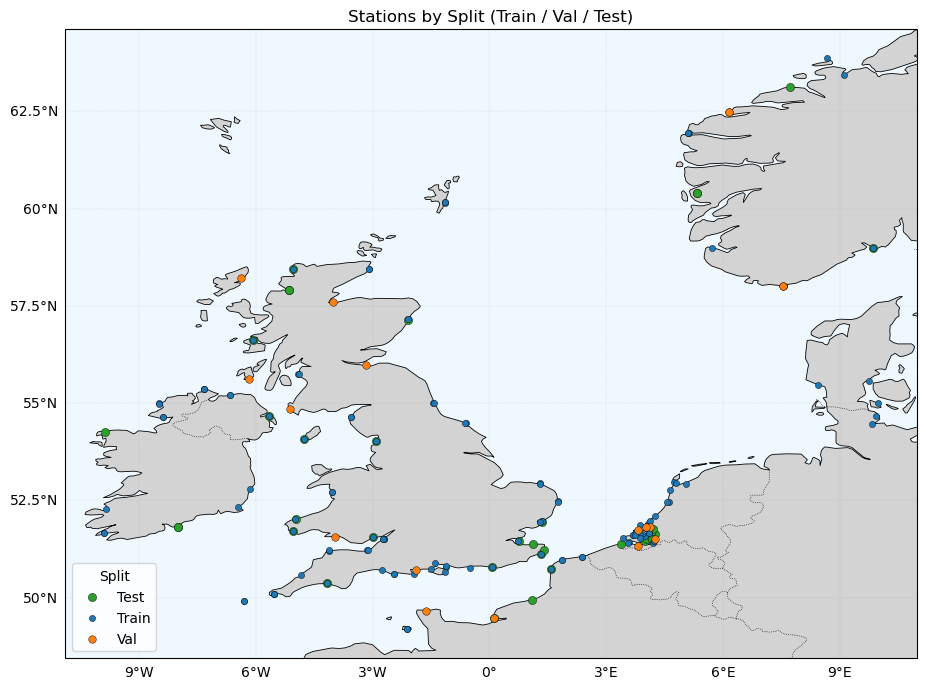

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- robust anchor from your xarray mapping ---
def to_minus180_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

# latlon_to_station: {(lat, lon) -> station_id}  (you created this earlier)
anchor_df = pd.DataFrame(
    [{'station': str(int(stn)), 'latitude': float(lat), 'longitude': float(lon)}
     for (lat, lon), stn in latlon_to_station.items()]
).drop_duplicates('station')

# normalize longitudes
anchor_df['longitude'] = to_minus180_180(anchor_df['longitude'])
anchor_df = anchor_df.sort_values('station').reset_index(drop=True)
print("[anchor] stations:", anchor_df['station'].nunique())

# --- reuse your splits; if not defined, make them now ---
def station_splits_from_anchor(anchor_df, train=0.70, val=0.10, seed=42):
    rng = np.random.default_rng(seed)
    stations = np.array(sorted(anchor_df['station'].astype(str).unique()))
    perm = rng.permutation(stations)
    n = len(perm); n_train = int(round(train*n)); n_val = int(round(val*n)); n_test = n-n_train-n_val
    return set(perm[:n_train]), set(perm[n_train:n_train+n_val]), set(perm[n_train+n_val:])

try:
    train_stn, val_stn, test_stn
except NameError:
    train_stn, val_stn, test_stn = station_splits_from_anchor(anchor_df, train=0.70, val=0.10, seed=42)

# --- build plotting table from anchor (no dropouts) ---
st_meta = anchor_df.copy()
def split_label(s):
    if s in train_stn: return "train"
    if s in val_stn:   return "val"
    if s in test_stn:  return "test"
    return "unknown"
st_meta['split'] = st_meta['station'].apply(split_label)

print(st_meta['split'].value_counts())

# --- map extent with padding ---
lon_min, lon_max = st_meta['longitude'].min(), st_meta['longitude'].max()
lat_min, lat_max = st_meta['latitude'].min(),  st_meta['latitude'].max()
d_lon = (lon_max - lon_min) if lon_max > lon_min else 1.0
d_lat = (lat_max - lat_min) if lat_max > lat_min else 1.0
pad = 0.05  # small pad since it’s global-ish now
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

# --- plot ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False; gl.top_labels = False

styles = {"train": dict(color="tab:blue", s=20),
          "val":   dict(color="tab:orange", s=30),
          "test":  dict(color="tab:green", s=35),
          "unknown": dict(color="gray", s=20)}

for split, df_s in st_meta.groupby('split'):
    ax.scatter(df_s['longitude'], df_s['latitude'],
               transform=proj, edgecolor="k", linewidth=0.3,
               zorder=5, label=split.capitalize(), **styles.get(split, styles['unknown']))

ax.legend(loc="lower left", title="Split")
ax.set_title("Stations by Split (Train / Val / Test)")
plt.tight_layout()
plt.show()


In [ ]:
# --- Tail-aware training & evaluation -----------------------------------------
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# --- helpers (as before) ---
def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2 or np.isclose(y_true.std(), 0) or np.isclose(y_pred.std(), 0):
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])

def eval_R2_R4(y_true, y_pred):
    r = pearson_r(y_true, y_pred)
    return {"R2": (r**2) if np.isfinite(r) else np.nan,
            "R4": (r**4) if np.isfinite(r) else np.nan}

def make_tail_weights(y, q=0.90, w_tail=5.0, p=1.0):
    """
    Upweight the largest |y| values: weight = w_tail * (|y|/t)^p for |y| >= t,
    else weight = 1. Returns (weights, threshold t).
    """
    a = np.abs(np.asarray(y, float))
    t = np.quantile(a, q)
    w = np.ones_like(a, dtype=float)
    tail = a >= t
    if np.all(~tail):  # safety
        return w, t
    w[tail] = w_tail * (a[tail] / (t + 1e-12))**p
    return w, t

# ---------- Build numeric matrices (reuse your predictors / masks / target) ----------
num_cols = [c for c in predictors if pd.api.types.is_numeric_dtype(merged[c])]
X_train = merged.loc[m_train, num_cols]
X_val   = merged.loc[m_val,   num_cols]
X_test  = merged.loc[m_test,  num_cols]

y_train = merged.loc[m_train, target].astype(float).values
y_val   = merged.loc[m_val,   target].astype(float).values
y_test  = merged.loc[m_test,  target].astype(float).values

# Drop constant / all-NaN cols
good = [c for c in X_train.columns if X_train[c].notna().any() and X_train[c].nunique(dropna=True) > 1]
X_train, X_val, X_test = X_train[good], X_val[good], X_test[good]

# ---------- Tail weights (focus on extremes) ----------
w_train, tail_thr = make_tail_weights(y_train, q=0.90, w_tail=5.0, p=1.0)
print(f"[tail] using |y| threshold t={tail_thr:.4g}; ~{(np.abs(y_train)>=tail_thr).mean()*100:.1f}% of train upweighted")

# ---------- Model ----------
RANDOM_SEED = 42
model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=4,
    random_state=RANDOM_SEED,
    tree_method="hist",
)

# Fit with sample weights; some versions support eval_sample_weight
fit_kwargs = dict(
    X=X_train, y=y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
    sample_weight=w_train,
)

model.fit(**fit_kwargs)

# ---------- Predictions ----------
yhat_tr = model.predict(X_train)
yhat_va = model.predict(X_val)
yhat_te = model.predict(X_test)

# ---------- Metrics: overall & tail-only ----------
# Overall
m_tr = {**eval_R2_R4(y_train, yhat_tr), "sklearn_R2": r2_score(y_train, yhat_tr) if len(y_train) else np.nan}
m_va = {**eval_R2_R4(y_val,   yhat_va), "sklearn_R2": r2_score(y_val,   yhat_va) if len(y_val)   else np.nan}
m_te = {**eval_R2_R4(y_test,  yhat_te), "sklearn_R2": r2_score(y_test,  yhat_te) if len(y_test)  else np.nan}

# Tail-only (use the SAME threshold computed on training)
tail_tr = np.abs(y_train) >= tail_thr
tail_va = np.abs(y_val)   >= tail_thr
tail_te = np.abs(y_test)  >= tail_thr

mt_tr = eval_R2_R4(y_train[tail_tr], yhat_tr[tail_tr]) if tail_tr.any() else {"R2": np.nan, "R4": np.nan}
mt_va = eval_R2_R4(y_val[tail_va],   yhat_va[tail_va]) if tail_va.any() else {"R2": np.nan, "R4": np.nan}
mt_te = eval_R2_R4(y_test[tail_te],  yhat_te[tail_te]) if tail_te.any() else {"R2": np.nan, "R4": np.nan}

print("\nXGBoost (tail-weighted)")
print("--- Overall ---")
print("Train:", m_tr); print("Val:", m_va); print("Test:", m_te)
print("\n--- Tail (|y| >= train 90th pct) ---")
print("Train tail:", mt_tr, f"(n={tail_tr.sum()})")
print("Val   tail:", mt_va, f"(n={tail_va.sum()})")
print("Test  tail:", mt_te, f"(n={tail_te.sum()})")

# ---------- Per-station tail R² on test ----------
test_idx = merged.index[m_test]
te_df = merged.loc[test_idx, ['station']].copy()
te_df['y_true'] = y_test
te_df['y_pred'] = yhat_te
te_df['is_tail'] = (np.abs(y_test) >= tail_thr)

rows = []
for sid, g in te_df.groupby('station'):
    g_tail = g[g['is_tail']]
    if len(g_tail) >= 5 and np.isfinite(g_tail['y_true'].std()) and np.isfinite(g_tail['y_pred'].std()):
        r = pearson_r(g_tail['y_true'], g_tail['y_pred'])
        rows.append({'station': str(sid), 'n_tail': len(g_tail),
                     'R_tail': r, 'R2_tail': (r**2) if np.isfinite(r) else np.nan})
    else:
        rows.append({'station': str(sid), 'n_tail': len(g_tail),
                     'R_tail': np.nan, 'R2_tail': np.nan})

st_tail_scores = pd.DataFrame(rows).sort_values('R2_tail', ascending=False).reset_index(drop=True)
print("\nPer-station tail R² (top 10):")
print(st_tail_scores.head(10))

[tail] using |y| threshold t=0.3376; ~10.0% of train upweighted

XGBoost (tail-weighted)
--- Overall ---
Train: {'R2': 0.1284358125382915, 'R4': 0.016495757942371157, 'sklearn_R2': -0.7102458495870185}
Val: {'R2': 0.04782379576906042, 'R4': 0.0022871154417608017, 'sklearn_R2': -0.20411393101592523}
Test: {'R2': 0.1007119571701981, 'R4': 0.010142898317051816, 'sklearn_R2': -0.3034042438650675}

--- Tail (|y| >= train 90th pct) ---
Train tail: {'R2': 0.3411145267003981, 'R4': 0.11635912032603662} (n=221219)
Val   tail: {'R2': 0.06460731136910867, 'R4': 0.00417410468234496} (n=30559)
Test  tail: {'R2': 0.16424790266816713, 'R4': 0.0269773735308917} (n=60759)

Per-station tail R² (top 10):
  station  n_tail    R_tail   R2_tail
0      14     442  0.918991  0.844544
1     108    2835  0.867917  0.753280
2     184    2401  0.863350  0.745374
3     185    2335  0.858542  0.737094
4     147    2827  0.854966  0.730967
5     165    2153  0.850924  0.724072
6       8     415  0.839539  0.704825
7

In [28]:
# pip install xgboost
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# --- helpers ---
def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size == 0 or np.allclose(y_true.std(), 0):
        return np.nan
    r = np.corrcoef(y_true, y_pred)[0, 1]
    return float(r)

def eval_R2_R4(y_true, y_pred):
    r = pearson_r(y_true, y_pred)
    return {"R2": (r**2) if np.isfinite(r) else np.nan,
            "R4": (r**4) if np.isfinite(r) else np.nan}

# ensure purely numeric feature matrix (drop non-numeric sneaking in)
num_cols = [c for c in predictors if pd.api.types.is_numeric_dtype(merged[c])]
X_train = merged.loc[m_train, num_cols]
X_val   = merged.loc[m_val,   num_cols]
X_test  = merged.loc[m_test,  num_cols]

y_train = merged.loc[m_train, target].astype(float)
y_val   = merged.loc[m_val,   target].astype(float)
y_test  = merged.loc[m_test,  target].astype(float)

# (optional) drop constant/all-NaN columns to be extra safe
good = [c for c in X_train.columns if X_train[c].notna().any() and X_train[c].nunique(dropna=True) > 1]
X_train, X_val, X_test = X_train[good], X_val[good], X_test[good]

# --- model (small, with early stopping) ---
RANDOM_SEED = 42
model = XGBRegressor(
    n_estimators=1500,        # early stopping will pick < this
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=4,
    random_state=RANDOM_SEED,
    tree_method="hist",       # memory-friendly
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

# --- predictions ---
yhat_tr = model.predict(X_train)
yhat_va = model.predict(X_val)
yhat_te = model.predict(X_test)

# --- metrics ---
# (1) classic sklearn R^2 (optional, for reference)
r2_tr = r2_score(y_train, yhat_tr) if len(y_train) else np.nan
r2_va = r2_score(y_val,   yhat_va) if len(y_val)   else np.nan
r2_te = r2_score(y_test,  yhat_te) if len(y_test)  else np.nan

# (2) requested R2 and R4 (based on Pearson correlation)
m_tr = eval_R2_R4(y_train, yhat_tr)
m_va = eval_R2_R4(y_val,   yhat_va)
m_te = eval_R2_R4(y_test,  yhat_te)

print("XGBoost with station-wise split")
print("\n--- Train ---")
print({**m_tr, "sklearn_R2": r2_tr})
print("\n--- Val ---")
print({**m_va, "sklearn_R2": r2_va})
print("\n--- Test ---")
print({**m_te, "sklearn_R2": r2_te})

# (optional) top features
imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 features:")
print(imp.head(20))

XGBoost with station-wise split

--- Train ---
{'R2': 0.5636063258565673, 'R4': 0.3176520905455392, 'sklearn_R2': 0.5600777408805104}

--- Val ---
{'R2': 0.1993545360325152, 'R4': 0.039742231036739406, 'sklearn_R2': 0.01776070201841695}

--- Test ---
{'R2': 0.43701270750177995, 'R4': 0.19098010651803626, 'sklearn_R2': 0.43695226953746735}

Top 20 features:
msl               0.267305
sp                0.087640
z37_10            0.045192
z46_10            0.037094
year              0.032375
tau_x             0.028565
tau_y             0.026803
z6_10             0.025208
z27_1             0.023008
z2_10             0.020324
z8_10             0.018492
v10               0.018388
d2m               0.018108
tide_range_12h    0.017822
z21_3             0.017768
t2m               0.017588
z36_10            0.017074
u10               0.016583
z15_10            0.016198
mwd               0.015488
dtype: float32


In [29]:
out = merged.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = yhat_te
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

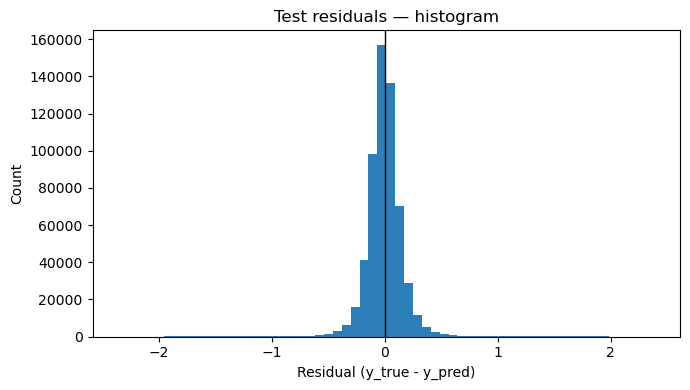

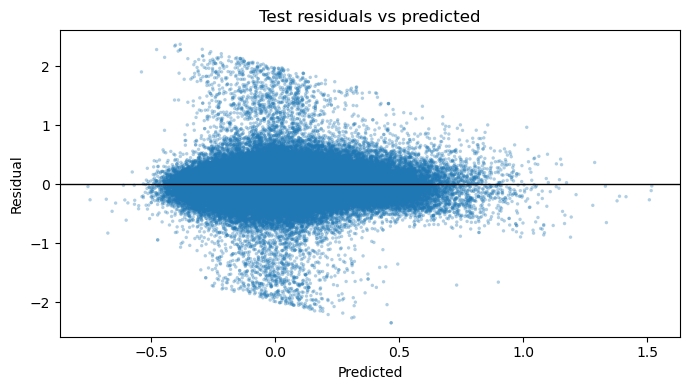

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If starting fresh, load what you saved:
# out = pd.read_parquet("test_predictions.parquet")

# Make sure the columns are named consistently
preds = out.rename(columns={"residual_pred": "y_pred", target: "y_true"}).copy()
preds["valid_time"] = pd.to_datetime(preds["valid_time"])
preds["residual"] = preds["y_true"] - preds["y_pred"]

# --- A) Residual histogram ---
plt.figure(figsize=(7,4))
plt.hist(preds["residual"].dropna(), bins=60, alpha=0.95)
plt.axvline(0, color="k", lw=1)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Test residuals — histogram")
plt.tight_layout()
plt.show()

# --- B) Residuals vs Predicted (heteroscedasticity check) ---
plt.figure(figsize=(7,4))
plt.scatter(preds["y_pred"], preds["residual"], s=6, alpha=0.35, edgecolors="none")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Test residuals vs predicted")
plt.tight_layout()
plt.show()


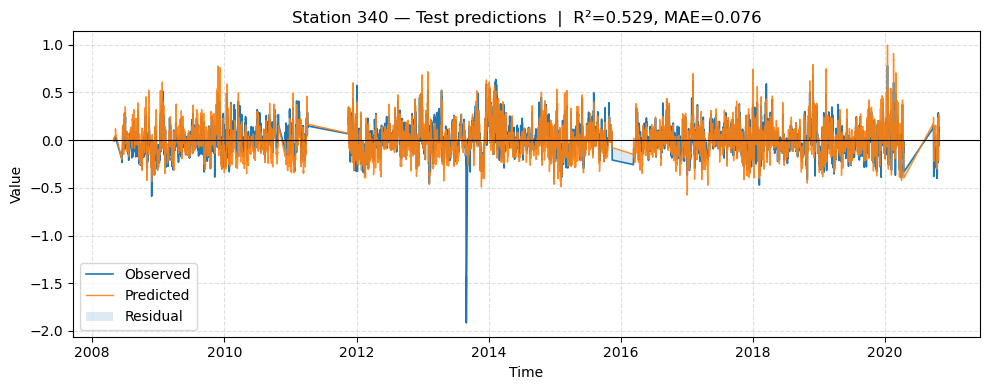

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[0])


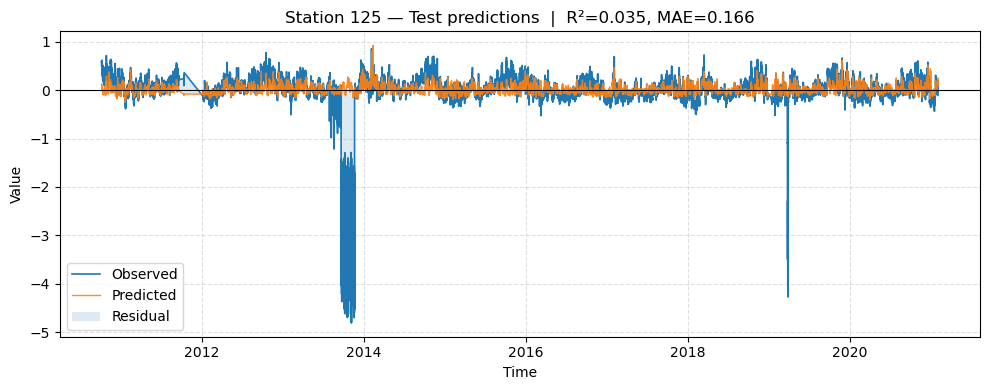

In [55]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[32])

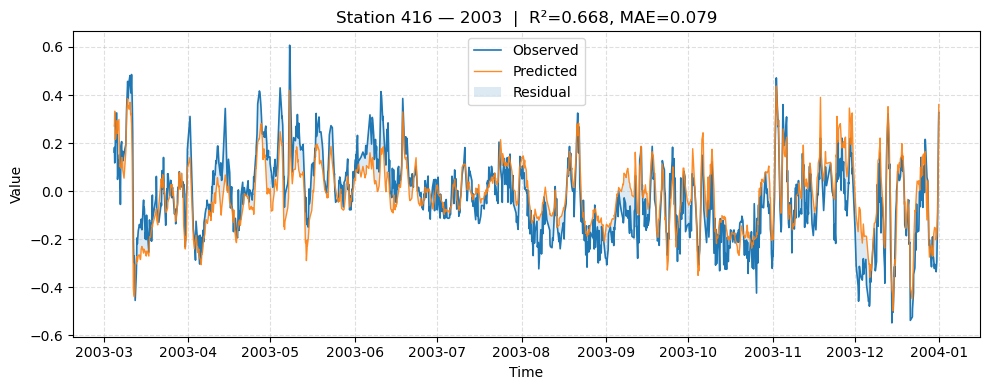

In [56]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id, year=None):
    g = preds[preds["station"] == station_id].sort_values("valid_time").copy()
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    
    if year is not None:
        g = g[g["valid_time"].dt.year == year]
        if g.empty:
            print(f"No test rows for station {station_id} in year {year}")
            return
    
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.title(f"Station {station_id} — {year if year else 'Full period'}  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[1], year=2003)


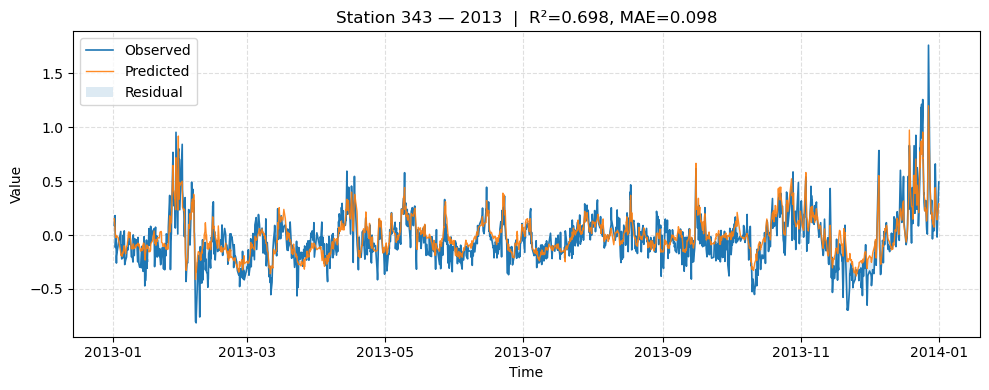

In [69]:
# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[0], year=2013)

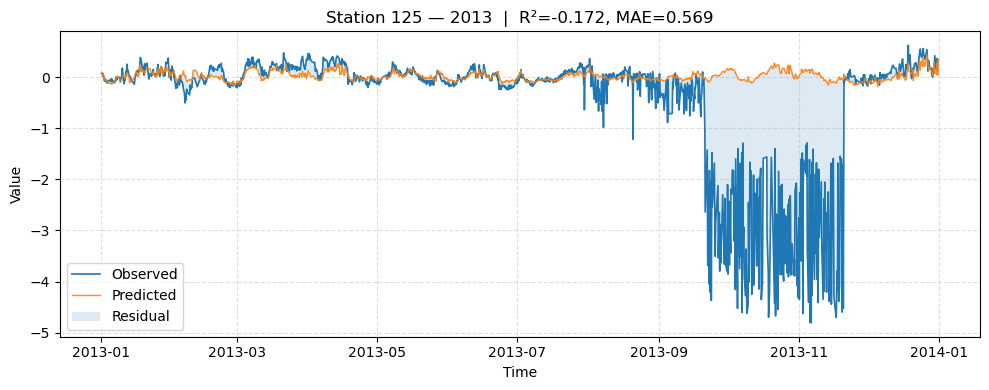

In [73]:
# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[8], year=2013)

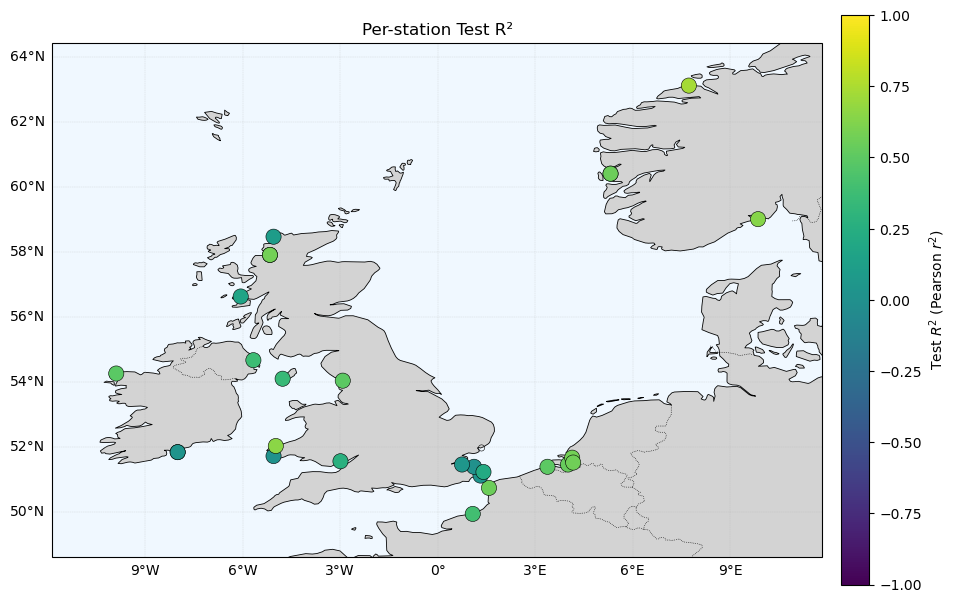

In [58]:
# pip install cartopy matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize

#LAT, LON = "station_latitude", "station_longitude"
LAT, LON = "latitude", "longitude"

def to_minus180_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def pearson_r(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    if len(a) < 2 or np.isclose(a.std(), 0) or np.isclose(b.std(), 0):
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

# ---------- 1) Gather per-row test predictions with coords ----------
te_idx = merged.index[m_test]
pred_df = merged.loc[te_idx, ['station', LAT, LON]].copy()
pred_df['y_true'] = np.asarray(y_test, dtype=float)
pred_df['y_pred'] = np.asarray(yhat_te, dtype=float)
pred_df['station'] = pred_df['station'].astype(str)

# ---------- 2) Per-station R2 (Pearson r^2) on the test set ----------
rows = []
for sid, g in pred_df.groupby('station', sort=True):
    r = pearson_r(g['y_true'], g['y_pred'])
    lat = g[LAT].dropna().iloc[0] if g[LAT].notna().any() else np.nan
    lon = g[LON].dropna().iloc[0] if g[LON].notna().any() else np.nan
    rows.append({
        'station': sid,
        LAT: lat,
        LON: lon,
        'n_test': len(g),
        'R': r,
        'R2': (r**2) if np.isfinite(r) else np.nan,
        'R4': (r**4) if np.isfinite(r) else np.nan,
    })

st_scores = pd.DataFrame(rows)
# normalize longitudes to [-180, 180] just in case
st_scores[LON] = to_minus180_180(st_scores[LON])

# ---------- 3) Plot R2 per station on a Cartopy map ----------
plot_df = st_scores.dropna(subset=[LAT, LON]).copy()

# Map extent with padding
lon_min, lon_max = float(plot_df[LON].min()), float(plot_df[LON].max())
lat_min, lat_max = float(plot_df[LAT].min()),  float(plot_df[LAT].max())
d_lon = (lon_max - lon_min) if lon_max > lon_min else 1.0
d_lat = (lat_max - lat_min) if lat_max > lat_min else 1.0
pad = 0.1
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)

# Basemap
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False; gl.top_labels = False

# Color by R2 (Pearson r^2 in [0,1])
norm = Normalize(vmin=-1.0, vmax=1.0)
sc = ax.scatter(
    plot_df[LON], plot_df[LAT],
    c=plot_df['R2'], cmap='viridis', norm=norm,
    s=np.clip(plot_df['n_test']*3, 20, 120),   # size ~ #test samples
    edgecolor='k', linewidth=0.4,
    transform=proj, zorder=5
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
cbar.set_label(r'Test $R^2$ (Pearson $r^2$)')
plt.title("Per-station Test R²")
plt.tight_layout()
plt.show()



In [ ]:
# --- replace your Section 4–6 with this MLP version ---

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# 4) MLP model (with impute+scale)
mlp_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler(with_mean=True, with_std=True)),
    ("mlp",     MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),  # try (256,128) or (512,256,128) if you want more capacity
        activation="relu",
        solver="adam",
        alpha=1e-4,              # L2 weight decay
        learning_rate_init=1e-3,
        batch_size=2048,         # tune depending on RAM
        max_iter=200,            # optimizer steps (epochs)
        early_stopping=True,     # uses 10% of TRAIN as internal validation
        n_iter_no_change=15,
        validation_fraction=0.1,
        shuffle=True,
        random_state=RANDOM_SEED,
        verbose=False,
    ))
])

mlp_pipe.fit(X_train, y_train)

# 5) Evaluate
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance (MLP):")
_ = evaluate("Train", X_train, y_train, mlp_pipe)
_ = evaluate(" Val ", X_val,   y_val,   mlp_pipe)
test_pred = evaluate("Test ", X_test,  y_test,  mlp_pipe)

# 6) Save test predictions (same as before)
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: test_predictions.parquet")

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Performance (MLP):
